## ResoNET: Few-Shot Personalization with Metric Learning

This notebook implements a Siamese-style network for audio recognition with few-shot personalization. It uses a YAMNet backbone, a custom embedding head, and Triplet Loss to map audio to a 128-dimensional L2-normalized embedding space.

### Mount Google Drive

Mounts your Google Drive to `/content/drive` to enable access to datasets and for saving model artifacts.

### 1. Environment Setup & Data Ingestion

First, we'll mount Google Drive to access the dataset, install necessary libraries, define constants, and merge the metadata CSVs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install Necessary Libraries

Installs required Python packages, including `tensorflow-hub` for the YAMNet model and `soundfile` for audio processing.

In [ ]:
!pip install -q tensorflow-hub soundfile

### Import Libraries and Define Constants

Imports essential libraries like TensorFlow, Pandas, NumPy, and Soundfile. Defines key constants such as base paths to the dataset on Google Drive, CSV file paths, audio directory paths, and audio processing parameters like `SAMPLING_RATE` and `AUDIO_LENGTH_SECONDS`.

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import soundfile as sf
from sklearn.model_selection import train_test_split

# Define constants and paths
BASE_DRIVE_PATH = '/content/drive/MyDrive/ResoNET dataset/'

# CSV paths
ESC50_CSV_PATH = os.path.join(BASE_DRIVE_PATH, 'Cleaned_ESC50.csv')
FSD50K_DEV_CSV_PATH = os.path.join(BASE_DRIVE_PATH, 'FSD50K_dev_cleaned.csv')
FSD50K_EVAL_CSV_PATH = os.path.join(BASE_DRIVE_PATH, 'FSDK50_eval_cleaned.csv')

# Audio folder paths
ESC50_AUDIO_DIR = os.path.join(BASE_DRIVE_PATH, 'ESC50_16000')
FSD50K_DEV_AUDIO_DIR = os.path.join(BASE_DRIVE_PATH, 'FSD50K.dev_audio_16k')
FSD50K_EVAL_AUDIO_DIR = os.path.join(BASE_DRIVE_PATH, 'FSD50K.eval_audio_16k')

# Audio parameters
SAMPLING_RATE = 16000
AUDIO_LENGTH_SECONDS = 5  # Example fixed audio length for processing
EMBEDDING_DIM = 128

print(f"Base Drive Path: {BASE_DRIVE_PATH}")
print(f"ESC50 CSV Path: {ESC50_CSV_PATH}")
print(f"FSD50K Dev CSV Path: {FSD50K_DEV_CSV_PATH}")
print(f"ESC50 Audio Directory: {ESC50_AUDIO_DIR}")

Base Drive Path: /content/drive/MyDrive/ResoNET dataset/
ESC50 CSV Path: /content/drive/MyDrive/ResoNET dataset/Cleaned_ESC50.csv
FSD50K Dev CSV Path: /content/drive/MyDrive/ResoNET dataset/FSD50K_dev_cleaned.csv
ESC50 Audio Directory: /content/drive/MyDrive/ResoNET dataset/ESC50_16000


### Check and Configure GPU

Checks for available GPU devices and configures TensorFlow to use them.

In [ ]:
print("Checking for GPU availability...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        print("GPU is available and configured.")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU devices found. Training will run on CPU.")

Checking for GPU availability...
1 Physical GPUs, 1 Logical GPUs
GPU is available and configured.


### Load and Merge Metadata, Assign Category IDs

Defines a helper function to load CSV metadata, construct full file paths, and add a source tag. It then loads metadata for ESC50, FSD50K development, and FSD50K evaluation datasets, merges them into a single DataFrame, and verifies file existence. Finally, it assigns unique integer category IDs to the `labels` column.

In [ ]:
# Load and merge the metadata CSVs
def load_and_prepare_csv(csv_path, audio_dir, source_tag):
    df = pd.read_csv(csv_path)
    df['filepath'] = df['fname'].apply(lambda x: os.path.join(audio_dir, str(x)+".wav"))
    df['source'] = source_tag
    return df

# Load each dataset
df_esc50 = load_and_prepare_csv(ESC50_CSV_PATH, ESC50_AUDIO_DIR, 'ESC50')
df_fsd50k_dev = load_and_prepare_csv(FSD50K_DEV_CSV_PATH, FSD50K_DEV_AUDIO_DIR, 'FSD50K_Dev')
df_fsd50k_eval = load_and_prepare_csv(FSD50K_EVAL_CSV_PATH, FSD50K_EVAL_AUDIO_DIR, 'FSD50K_Eval')

# Merge all dataframes
full_df = pd.concat([df_esc50, df_fsd50k_dev, df_fsd50k_eval], ignore_index=True)

# Ensure all files exist
full_df['file_exists'] = full_df['filepath'].apply(os.path.exists)
print(f"Total entries before filtering non-existent files: {len(full_df)}")
full_df = full_df[full_df['file_exists']].drop(columns=['file_exists'])
print(f"Total entries after filtering non-existent files: {len(full_df)}")

# Display the first few rows and general info of the merged dataframe
print("\nMerged DataFrame Info:")
full_df.info()
print("\nMerged DataFrame Head:")
display(full_df.head())

# Basic sanity check on classes/categories
print("\nUnique categories in the merged dataset:")
print(full_df['labels'].value_counts())

# Assign unique integer IDs to each category for consistent class labels
full_df['category_id'] = full_df['labels'].astype('category').cat.codes
print("\nDataFrame head with category_id:")
display(full_df.head())

Total entries before filtering non-existent files: 3457
Total entries after filtering non-existent files: 3457

Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3457 entries, 0 to 3456
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fname     3457 non-null   object 
 1   fold      200 non-null    float64
 2   target    200 non-null    float64
 3   labels    3457 non-null   object 
 4   esc10     200 non-null    object 
 5   src_file  200 non-null    float64
 6   take      200 non-null    object 
 7   filepath  3457 non-null   object 
 8   source    3457 non-null   object 
 9   mids      3257 non-null   object 
 10  split     2253 non-null   object 
dtypes: float64(3), object(8)
memory usage: 297.2+ KB

Merged DataFrame Head:


,fname,fold,target,labels,esc10,src_file,take,filepath,source,mids,split
0,1-101336-A-30,1.0,30.0,door_wood_knock,False,101336.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN
1,1-103995-A-30,1.0,30.0,door_wood_knock,False,103995.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN
2,1-103999-A-30,1.0,30.0,door_wood_knock,False,103999.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN
3,1-13571-A-46,1.0,46.0,church_bells,False,13571.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN
4,1-13572-A-46,1.0,46.0,church_bells,False,13572.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN



Unique categories in the merged dataset:
labels
Doorbell           1679
Alarm              1578
door_wood_knock      40
clock_alarm          40
church_bells         40
siren                40
glass_breaking       40
Name: count, dtype: int64

DataFrame head with category_id:


,fname,fold,target,labels,esc10,src_file,take,filepath,source,mids,split,category_id
0,1-101336-A-30,1.0,30.0,door_wood_knock,False,101336.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN,4
1,1-103995-A-30,1.0,30.0,door_wood_knock,False,103995.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN,4
2,1-103999-A-30,1.0,30.0,door_wood_knock,False,103999.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN,4
3,1-13571-A-46,1.0,46.0,church_bells,False,13571.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN,2
4,1-13572-A-46,1.0,46.0,church_bells,False,13572.0,A,/content/drive/MyDrive/ResoNET dataset/ESC50_1...,ESC50,NaN,NaN,2


### Define Audio Preprocessing and Triplet Generator

Implements `load_and_preprocess_audio` to handle audio loading (using `soundfile`), conversion to mono, resampling to a target sample rate (16kHz), and padding/trimming to a fixed length (5 seconds). It also defines the `TripletGenerator` class, a `tf.keras.utils.Sequence` subclass, responsible for creating batches of (anchor, positive, negative) audio triplets for training. Each triplet ensures the anchor and positive belong to the same category, while the negative belongs to a different category.

### 2. Triplet Data Generator

This section implements a `tf.keras.utils.Sequence` based data generator to create (anchor, positive, negative) triplets. It includes helper functions for loading and preprocessing audio files (resampling to 16kHz and ensuring a fixed length).

In [ ]:
import random
import librosa

# Helper function to load and preprocess audio
def load_and_preprocess_audio(filepath, sample_rate=SAMPLING_RATE, audio_length_seconds=AUDIO_LENGTH_SECONDS):
    try:
        # Load audio using soundfile
        audio, sr = sf.read(filepath, dtype='float32')

        # If stereo, convert to mono by averaging channels
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        # Resample if necessary
        # librosa.resample expects float input, which is handled by sf.read(dtype='float32')
        if sr != sample_rate:
            audio = librosa.resample(y=audio, orig_sr=sr, target_sr=sample_rate)

        # Pad or trim audio to a fixed length
        target_length = sample_rate * audio_length_seconds
        if len(audio) < target_length:
            padding = target_length - len(audio)
            audio = np.pad(audio, (0, padding), mode='constant')
        elif len(audio) > target_length:
            audio = audio[:target_length]

        # Ensure the audio is 1D
        audio = audio.astype(np.float32)
        return audio
    except Exception as e:
        print(f"Error processing {filepath}: {e}")
        return None


class TripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, sample_rate=SAMPLING_RATE, audio_length_seconds=AUDIO_LENGTH_SECONDS, shuffle=True):
        self.dataframe = dataframe.copy()
        self.batch_size = batch_size
        self.sample_rate = sample_rate
        self.audio_length_seconds = audio_length_seconds
        self.shuffle = shuffle
        self.categories = self.dataframe['category_id'].unique()
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.dataframe = self.dataframe.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch_indices = self.dataframe.index[index * self.batch_size:(index + 1) * self.batch_size]
        return self.__data_generation(batch_indices)

    def __data_generation(self, batch_indices):
        anchors = []
        positives = []
        negatives = []

        for i in batch_indices:
            anchor_row = self.dataframe.loc[i]
            anchor_category_id = anchor_row['category_id']

            # Anchor audio
            anchor_audio = load_and_preprocess_audio(anchor_row['filepath'], self.sample_rate, self.audio_length_seconds)
            if anchor_audio is None: continue

            # Positive sample: same category, different file
            positive_candidates = self.dataframe[
                (self.dataframe['category_id'] == anchor_category_id) &
                (self.dataframe['filepath'] != anchor_row['filepath'])
            ]
            if len(positive_candidates) > 0:
                positive_row = positive_candidates.sample(n=1).iloc[0]
                positive_audio = load_and_preprocess_audio(positive_row['filepath'], self.sample_rate, self.audio_length_seconds)
                if positive_audio is None: continue
            else:
                # If no other positive candidates, use the anchor itself as positive
                positive_audio = anchor_audio

            # Negative sample: different category
            negative_candidates = self.dataframe[
                (self.dataframe['category_id'] != anchor_category_id)
            ]
            if len(negative_candidates) > 0:
                negative_row = negative_candidates.sample(n=1).iloc[0]
                negative_audio = load_and_preprocess_audio(negative_row['filepath'], self.sample_rate, self.audio_length_seconds)
                if negative_audio is None: continue
            else:
                # If no negative candidates, select a random one from the whole dataset
                # Or, for safety, pick another random one that is not anchor_row and not positive_row
                other_candidates = self.dataframe[
                    (self.dataframe['filepath'] != anchor_row['filepath'])
                ]
                if len(other_candidates) > 0:
                    negative_row = other_candidates.sample(n=1).iloc[0]
                    negative_audio = load_and_preprocess_audio(negative_row['filepath'], self.sample_rate, self.audio_length_seconds)
                else:
                    negative_audio = anchor_audio # Last resort if only one file exists in the whole dataset

            if anchor_audio is not None and positive_audio is not None and negative_audio is not None:
                anchors.append(anchor_audio)
                positives.append(positive_audio)
                negatives.append(negative_audio)

        return (tf.stack(anchors), tf.stack(positives), tf.stack(negatives))


### Split Data and Verify Triplet Generators

Splits the `full_df` into training and validation sets using `train_test_split` with stratification to maintain class distribution. It then instantiates `TripletGenerator` objects for both training and validation and verifies their output shapes and data types by fetching a single batch.

In [ ]:
# Split data into training and validation sets
train_df, val_df = train_test_split(full_df, test_size=0.2, stratify=full_df['category_id'], random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

train_generator = TripletGenerator(train_df, batch_size=4, shuffle=True)
val_generator = TripletGenerator(val_df, batch_size=4, shuffle=False)

# Get one batch from the generator to verify its output shape
print("\nVerifying TripletGenerator output:")
anchor_batch, positive_batch, negative_batch = train_generator[0]

print(f"Anchor batch shape: {anchor_batch.shape}") # Should be (batch_size, SAMPLING_RATE * AUDIO_LENGTH_SECONDS)
print(f"Positive batch shape: {positive_batch.shape}")
print(f"Negative batch shape: {negative_batch.shape}")

# Check data types
print(f"Anchor batch dtype: {anchor_batch.dtype}")
print(f"Positive batch dtype: {positive_batch.dtype}")
print(f"Negative batch dtype: {negative_batch.dtype}")

Training samples: 2765
Validation samples: 692

Verifying TripletGenerator output:
Anchor batch shape: (4, 80000)
Positive batch shape: (4, 80000)
Negative batch shape: (4, 80000)
Anchor batch dtype: <dtype: 'float32'>
Positive batch dtype: <dtype: 'float32'>
Negative batch dtype: <dtype: 'float32'>


### YAMNet Feature Extractor Layer

Loads the pre-trained YAMNet model from TensorFlow Hub and wraps its embedding extraction logic into a custom Keras layer, `YAMNetFeatureExtractor`. This layer processes batched audio waveforms, extracts YAMNet's frame-level embeddings, and then averages them to produce a single 1024-dimensional embedding per audio clip. YAMNet's weights are frozen to use it as a fixed feature extractor.

### 3. Model Architecture:

This section defines the Siamese-style network. It utilizes YAMNet from TensorFlow Hub as a frozen feature extractor and adds a custom projection head that outputs L2-normalized 128-dimensional embeddings.

In [ ]:
# Load YAMNet model from TensorFlow Hub
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

# YAMNet outputs 3 things: scores, embeddings, and log_mel_spectrogram
# We are interested in the embeddings, which are 1024-dimensional.
# YAMNet expects a 1-D float32 Tensor of shape (num_samples,) containing audio at 16 kHz.

def yamnet_features(waveform):
    waveform = tf.cast(waveform, tf.float32)
    if len(waveform.shape) > 1:
        waveform = tf.squeeze(waveform)

    _, embeddings, _ = yamnet_model(waveform)
    return embeddings

# Create a Keras layer from the hub model for easier integration
@tf.keras.utils.register_keras_serializable()
class YAMNetFeatureExtractor(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(YAMNetFeatureExtractor, self).__init__(**kwargs)
        self.yamnet_model = hub.load(yamnet_model_handle)
        # Freeze YAMNet weights
        self.yamnet_model.trainable = False

    def call(self, inputs):
        # YAMNet expects a 1-D float32 Tensor of shape (num_samples,) containing audio at 16 kHz.
        # Our input will be (batch_size, num_samples), so we need to process each independently.
        # This can be handled by map_fn or by designing the model to take a single audio clip.
        # For training, we'll process each audio clip in the batch.

        # Process each audio sample in the batch to get its embedding
        # tf.map_fn applies a function to each slice of a tensor along the first dimension.
        # The output of yamnet_model for a single waveform is (num_patches, 1024)
        # We need to average these patches to get a single 1024-D embedding per audio clip.

        # Let's assume input shape is (batch_size, audio_samples)
        batch_size = tf.shape(inputs)[0]

        def process_single_audio(audio_tensor):
            _, yamnet_embeddings, _ = self.yamnet_model(audio_tensor)
            # YAMNet outputs embeddings for 0.96-second frames. Average them for a single embedding per clip.
            return tf.reduce_mean(yamnet_embeddings, axis=0)

        # Apply to each audio sample in the batch
        batch_embeddings = tf.map_fn(process_single_audio, inputs, fn_output_signature=tf.TensorSpec(shape=(1024,), dtype=tf.float32))
        return batch_embeddings

print("YAMNet model loaded and feature extractor layer defined.")

YAMNet model loaded and feature extractor layer defined.


### 4. Triplet Loss Implementation

This section defines the custom Triplet Loss function. The goal of triplet loss is to ensure that an anchor sample's embedding is closer to positive samples (same class) than to negative samples (different class) by at least a certain margin. Mathematically, for an anchor A, a positive P, and a negative N, we want to minimize `max(0, ||A-P||² - ||A-N||² + margin)`.

In [ ]:
class TripletLoss:
    def __init__(self, margin=1.0, name='triplet_loss'):
        self.margin = margin
        self.name = name

    # Modified call signature to directly accept embeddings
    def __call__(self, anchor_embeddings, positive_embeddings, negative_embeddings):
        # Distance between anchor and positive
        distance_positive = tf.reduce_sum(tf.square(anchor_embeddings - positive_embeddings), axis=-1)

        # Distance between anchor and negative
        distance_negative = tf.reduce_sum(tf.square(anchor_embeddings - negative_embeddings), axis=-1)

        # Triplet Loss calculation
        # max(0, ||A-P||^2 - ||A-N||^2 + margin)
        loss = tf.maximum(0.0, distance_positive - distance_negative + self.margin)

        return tf.reduce_mean(loss)

# Instantiate the TripletLoss
triplet_loss = TripletLoss(margin=0.2) # A common margin value

print("TripletLoss function defined with margin: ", triplet_loss.margin)

TripletLoss function defined with margin:  0.2


### 5. Custom Training Loop

Since Triplet Loss is typically applied to three distinct outputs (anchor, positive, negative), it's more convenient to implement a custom training loop rather than relying on `model.compile` and `model.fit` directly. This allows explicit control over how the anchor, positive, and negative samples are processed and how the loss is computed.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def train_step(anchor_audio, positive_audio, negative_audio):
    with tf.GradientTape() as tape:
        # Generate embeddings for all three inputs
        anchor_embeddings = embedding_model(anchor_audio, training=True)
        positive_embeddings = embedding_model(positive_audio, training=True)
        negative_embeddings = embedding_model(negative_audio, training=True)

        # Calculate triplet loss using the embeddings
        # Modified call to TripletLoss
        loss = triplet_loss(anchor_embeddings, positive_embeddings, negative_embeddings)

    # Compute gradients and apply them
    gradients = tape.gradient(loss, embedding_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, embedding_model.trainable_variables))

    return loss

def validate_step(anchor_audio, positive_audio, negative_audio):
    # Generate embeddings for all three inputs (not training mode)
    anchor_embeddings = embedding_model(anchor_audio, training=False)
    positive_embeddings = embedding_model(positive_audio, training=False)
    negative_embeddings = embedding_model(negative_audio, training=False)

    # Calculate triplet loss
    # Modified call to TripletLoss
    loss = triplet_loss(anchor_embeddings, positive_embeddings, negative_embeddings)
    return loss

# Training loop parameters
epochs = 5

print("Custom training and validation steps defined.")

Custom training and validation steps defined.


### Build ResoNET Embedding Model

Defines the `build_embedding_model` function, which constructs the ResoNET architecture. It takes the preprocessed audio input, passes it through the `YAMNetFeatureExtractor`, and then applies a custom projection head consisting of `Dense` layers with `BatchNormalization`. The final output is a 128-dimensional L2-normalized embedding, suitable for metric learning tasks.

In [ ]:
def build_embedding_model(input_shape, embedding_dim):
    inputs = tf.keras.Input(shape=input_shape, name='audio_input')

    # YAMNet feature extractor
    yamnet_features = YAMNetFeatureExtractor(name='yamnet_feature_extractor')(inputs)

    # Custom Projection Head
    x = tf.keras.layers.Dense(512, activation='relu', name='embedding_dense_1')(yamnet_features)
    x = tf.keras.layers.BatchNormalization(name='embedding_bn_1')(x)
    x = tf.keras.layers.Dense(256, activation='relu', name='embedding_dense_2')(x)
    x = tf.keras.layers.BatchNormalization(name='embedding_bn_2')(x)

    # Output embedding layer, followed by L2 normalization
    embeddings = tf.keras.layers.Dense(embedding_dim, activation=None, name='embedding_output')(x)
    embeddings = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1), output_shape=(embedding_dim,), name='l2_normalize')(embeddings)

    model = tf.keras.Model(inputs=inputs, outputs=embeddings, name='ResoNET_Embedding_Model')
    return model

# Create the embedding model
input_shape = (SAMPLING_RATE * AUDIO_LENGTH_SECONDS,) # e.g., (16000 * 5,) = (80000,)
embedding_model = build_embedding_model(input_shape, EMBEDDING_DIM)

embedding_model.summary()

print(f"ResoNET Embedding Model built with input shape {input_shape} and output embedding dimension {EMBEDDING_DIM}.")

Model: "ResoNET_Embedding_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)        │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ yamnet_feature_extractor        │ (None, 1024)           │             0 │
│ (YAMNetFeatureExtractor)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dense_1 (Dense)       │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_bn_1                  │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dense_2 (Dense)       │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_bn_2                  │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_output (Dense)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,096 (2.64 MB)

 Trainable params: 690,560 (2.63 MB)

 Non-trainable params: 1,536 (6.00 KB)

ResoNET Embedding Model built with input shape (80000,) and output embedding dimension 128.


### 6. Model Training

This section implements the full training loop using the custom `train_step` and `validate_step` functions defined earlier. It iterates through the `TripletGenerator` for both training and validation datasets over a specified number of epochs.

In [ ]:
print("Starting training...")

history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    total_train_loss = 0.0
    num_train_batches = 0

    # Training loop
    for batch_idx, (anchor_batch, positive_batch, negative_batch) in enumerate(train_generator):
        loss = train_step(anchor_batch, positive_batch, negative_batch)
        total_train_loss += loss.numpy()
        num_train_batches += 1
        if batch_idx % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_generator)} - Train Loss: {loss.numpy():.4f}")

    avg_train_loss = total_train_loss / num_train_batches
    history['train_loss'].append(avg_train_loss)
    print(f"Epoch {epoch+1} - Avg Train Loss: {avg_train_loss:.4f}")

    # Validation loop
    total_val_loss = 0.0
    num_val_batches = 0
    for batch_idx, (anchor_batch, positive_batch, negative_batch) in enumerate(val_generator):
        loss = validate_step(anchor_batch, positive_batch, negative_batch)
        total_val_loss += loss.numpy()
        num_val_batches += 1

    avg_val_loss = total_val_loss / num_val_batches
    history['val_loss'].append(avg_val_loss)
    print(f"Epoch {epoch+1} - Avg Val Loss: {avg_val_loss:.4f}")

print("Training complete.")

Starting training...

Epoch 1/5
  Batch 1/691 - Train Loss: 0.2586
  Batch 51/691 - Train Loss: 0.6325
  Batch 101/691 - Train Loss: 0.1441
  Batch 151/691 - Train Loss: 0.0125
  Batch 201/691 - Train Loss: 0.2645
  Batch 251/691 - Train Loss: 0.0000
  Batch 301/691 - Train Loss: 0.4077
  Batch 351/691 - Train Loss: 0.3893
  Batch 401/691 - Train Loss: 0.0578
  Batch 451/691 - Train Loss: 0.5391
  Batch 501/691 - Train Loss: 0.1213
  Batch 551/691 - Train Loss: 0.4324
  Batch 601/691 - Train Loss: 0.1690
  Batch 651/691 - Train Loss: 0.2947
Epoch 1 - Avg Train Loss: 0.2291
Epoch 1 - Avg Val Loss: 0.2736

Epoch 2/5
  Batch 1/691 - Train Loss: 0.2222
  Batch 51/691 - Train Loss: 0.0000
  Batch 101/691 - Train Loss: 0.2348
  Batch 151/691 - Train Loss: 0.0740
  Batch 201/691 - Train Loss: 0.3846
  Batch 251/691 - Train Loss: 0.3414
  Batch 301/691 - Train Loss: 0.0000
  Batch 351/691 - Train Loss: 0.5114
  Batch 401/691 - Train Loss: 0.2569
  Batch 451/691 - Train Loss: 0.2448
  Batch 501

### Plot Training and Validation Loss

Visualizes the training and validation loss recorded during the training process. This plot helps to monitor the model's learning progress and identify potential issues like overfitting or underfitting.

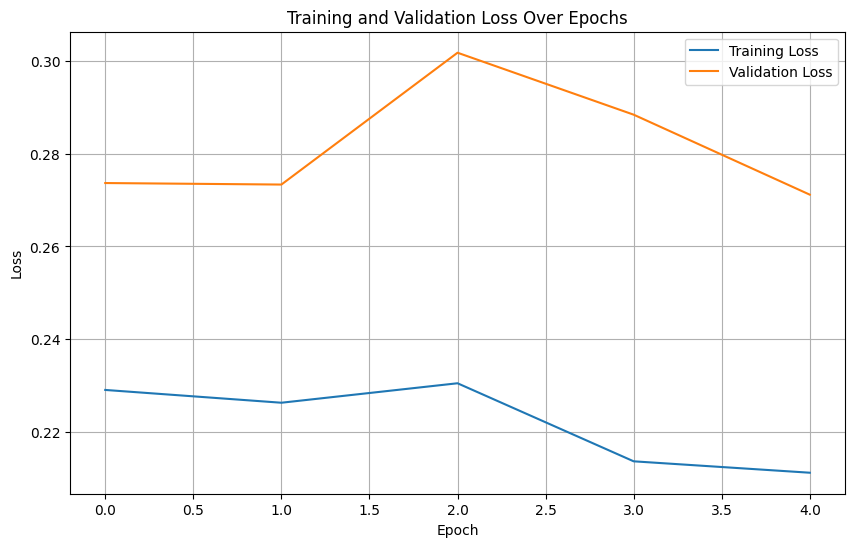

In [ ]:
import matplotlib.pyplot as plt

# Plotting the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Perform Qualitative Model Evaluation

Conducts a qualitative evaluation of the trained `embedding_model`. It defines a helper function `get_embeddings` to process audio files and obtain their embeddings. It then selects a subset of validation samples, computes their embeddings and the embeddings for the entire validation set. Using cosine similarity, it finds and displays the 5 nearest neighbors in the embedding space for each selected anchor sample, along with their labels and similarity scores.

### 7. Model Evaluation

We will perform a qualitative evaluation by taking a few samples from the validation set and finding their nearest neighbors in the embedding space. This helps visualize if the model is learning to cluster similar sounds together.

In [ ]:
# Helper function to get embeddings for a list of filepaths
def get_embeddings(filepaths):
    embeddings = []
    for fp in filepaths:
        audio = load_and_preprocess_audio(fp)
        if audio is not None:
            audio_tensor = tf.expand_dims(audio, axis=0) # Add batch dimension
            embedding = embedding_model(audio_tensor, training=False)
            embeddings.append(embedding.numpy().squeeze()) # Remove batch dim and convert to numpy
    return np.array(embeddings)

# Select a small subset of validation data for evaluation
eval_samples_df = val_df.sample(n=10, random_state=42) # Pick 10 random samples

# Get embeddings for the evaluation samples and the entire validation set
eval_filepaths = eval_samples_df['filepath'].tolist()
val_filepaths = val_df['filepath'].tolist()

eval_embeddings = get_embeddings(eval_filepaths)
all_val_embeddings = get_embeddings(val_filepaths)

print(f"Generated {len(eval_embeddings)} embeddings for evaluation samples.")
print(f"Generated {len(all_val_embeddings)} embeddings for the entire validation set.")

# Perform nearest neighbor search
# For each evaluation sample, find its 5 nearest neighbors in the full validation set
from sklearn.metrics.pairwise import cosine_similarity

print("\nNearest Neighbor Analysis (Examples):")
for i, (anchor_idx, anchor_row) in enumerate(eval_samples_df.iterrows()):
    anchor_embedding = eval_embeddings[i].reshape(1, -1)

    # Calculate cosine similarity between anchor and all validation embeddings
    similarities = cosine_similarity(anchor_embedding, all_val_embeddings).squeeze()

    # Get indices of top 6 most similar (first one will be itself)
    top_indices = np.argsort(similarities)[::-1][1:6] # Exclude self

    print(f"\n--- Anchor Sample {i+1} ---")
    print(f"File: {os.path.basename(anchor_row['filepath'])}")
    print(f"Label: {anchor_row['labels']}")

    print("  Top 5 Nearest Neighbors:")
    for rank, nn_idx in enumerate(top_indices):
        nn_row = val_df.iloc[nn_idx]
        print(f"    {rank+1}. File: {os.path.basename(nn_row['filepath'])}, Label: {nn_row['labels']}, Similarity: {similarities[nn_idx]:.4f}")

Generated 10 embeddings for evaluation samples.
Generated 692 embeddings for the entire validation set.

Nearest Neighbor Analysis (Examples):

--- Anchor Sample 1 ---
File: 90189.wav
Label: Alarm
  Top 5 Nearest Neighbors:
    1. File: 178537.wav, Label: Alarm, Similarity: 0.9752
    2. File: 410756.wav, Label: Alarm, Similarity: 0.9647
    3. File: 158427.wav, Label: Alarm, Similarity: 0.9511
    4. File: 135509.wav, Label: Alarm, Similarity: 0.9312
    5. File: 328188.wav, Label: Alarm, Similarity: 0.9233

--- Anchor Sample 2 ---
File: 253928.wav
Label: Alarm
  Top 5 Nearest Neighbors:
    1. File: 135584.wav, Label: Alarm, Similarity: 0.9921
    2. File: 66295.wav, Label: Alarm, Similarity: 0.9736
    3. File: 337655.wav, Label: Alarm, Similarity: 0.9705
    4. File: 59807.wav, Label: Alarm, Similarity: 0.9688
    5. File: 341621.wav, Label: Alarm, Similarity: 0.9662

--- Anchor Sample 3 ---
File: 112332.wav
Label: Doorbell
  Top 5 Nearest Neighbors:
    1. File: 414315.wav, Label:

### Save the Trained Embedding Model

Saves the trained `embedding_model` to Google Drive.

In [ ]:
import datetime

save_path = os.path.join(BASE_DRIVE_PATH, 'saved_models')
os.makedirs(save_path, exist_ok=True)

timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_filename = f"novelty_model.keras" # Added .keras extension
full_model_path = os.path.join(save_path, model_filename)

# Save the model
embedding_model.save(full_model_path)

print(f"Model saved successfully to: {full_model_path}")

Model saved successfully to: /content/drive/MyDrive/ResoNET dataset/saved_models/novelty_model.keras


In [ ]:
import tensorflow as tf
import os

# Define a path for the SavedModel format
saved_model_dir = os.path.join(BASE_DRIVE_PATH, 'saved_models', 'resonet_saved_model')

# 1. Save the trained embedding model in SavedModel format
# This is often more robust for TFLite conversion, especially with custom layers or hub models
embedding_model.export(saved_model_dir) # Use .export() for SavedModel format
print(f"Model saved in SavedModel format to: {saved_model_dir}")

# 2. Initialize the TFLite Converter from the SavedModel directory
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# 3. Apply Optimization (Quantization)
# This makes the model 'mobile-ready' by optimizing for size and latency
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Convert the model
tflite_model = converter.convert()

# 5. Save the .tflite file
tflite_save_path = 'resonet_model.tflite'
with open(tflite_save_path, 'wb') as f:
    f.write(tflite_model)

print(f"Success! Model converted and saved to: {tflite_save_path}")

Saved artifact at '/content/drive/MyDrive/ResoNET dataset/saved_models/resonet_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80000), dtype=tf.float32, name='audio_input')
Output Type:
  TensorSpec(shape=(None, 128), dtype=tf.float32, name=None)
Captures:
  135644232804944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232803216: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  135644232804752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232804560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232804368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232803984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232802256: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  135644232803792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232803600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135644232803408: TensorSpec(sh